# Implement Autocorrelation Function with Exponential Weighting (EW-ACF)


In [ ]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
from custom_lstm.utils import std_acf, ew_acf, EWACFEngine

$$\mu_t = \lambda \mu_{t-1} + (1 - \lambda) x_t$$
$$V_t = \lambda V_{t-1} + (1 - \lambda) (x_t - \mu_t)^2$$
$$S_t(k) = \lambda S_{t-1}(k) + (1 - \lambda) (x_t - \mu_t)(x_{t-k} - \mu_{t-k})$$
$$\rho_t(k) = \frac{S_t(k)}{\sqrt{V_t \cdot V_{t-k}}}$$


In [108]:
time_series = pd.read_csv("C:/Users/Luis/Documents/ML-AI-Projects/custom-lstm/data/preprocessed/total_sunspots.csv").to_numpy().squeeze()

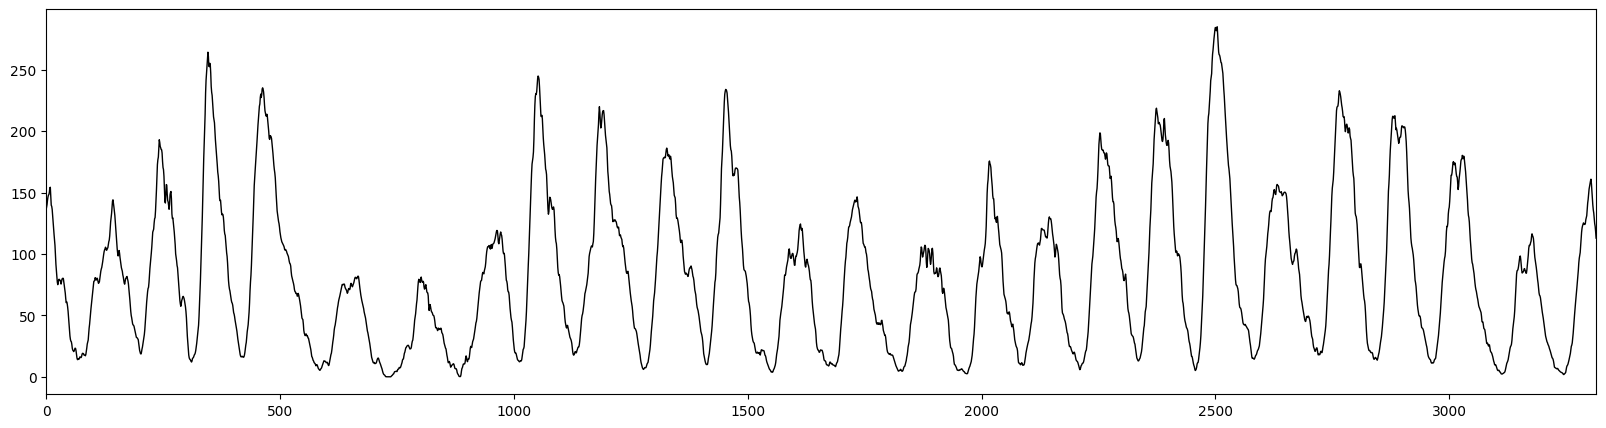

In [109]:
# Plot Complete Time Series

plt.figure(figsize=(20, 5))
plt.margins(x=0)
plt.plot(time_series, color="black", linewidth=1)

In [112]:
LAGS = [1, 2, 4, 8]
LAMBDA = 0.9

# Plot EW-ACF sequence
ew_acf_seq = []
std_acf_seq = []

# EW-ACF sequence
ew_acf_seq = ew_acf(time_series, lag=LAGS[0], lambda_=LAMBDA, last_only=False)

# Standard ACF sequence
for i in range(1, len(time_series)):
    std_acf_seq.append(std_acf(time_series[: i + 1], lag=1))

# EWACFEngine sequence
tensor = torch.Tensor(time_series).unsqueeze(0).unsqueeze(2)
print(tensor.shape)
engine = EWACFEngine(lambda_=LAMBDA, lags=LAGS)
engine_seq = engine(tensor).squeeze()
print(engine_seq.shape)

torch.Size([1, 3315, 1])
torch.Size([3307, 4])


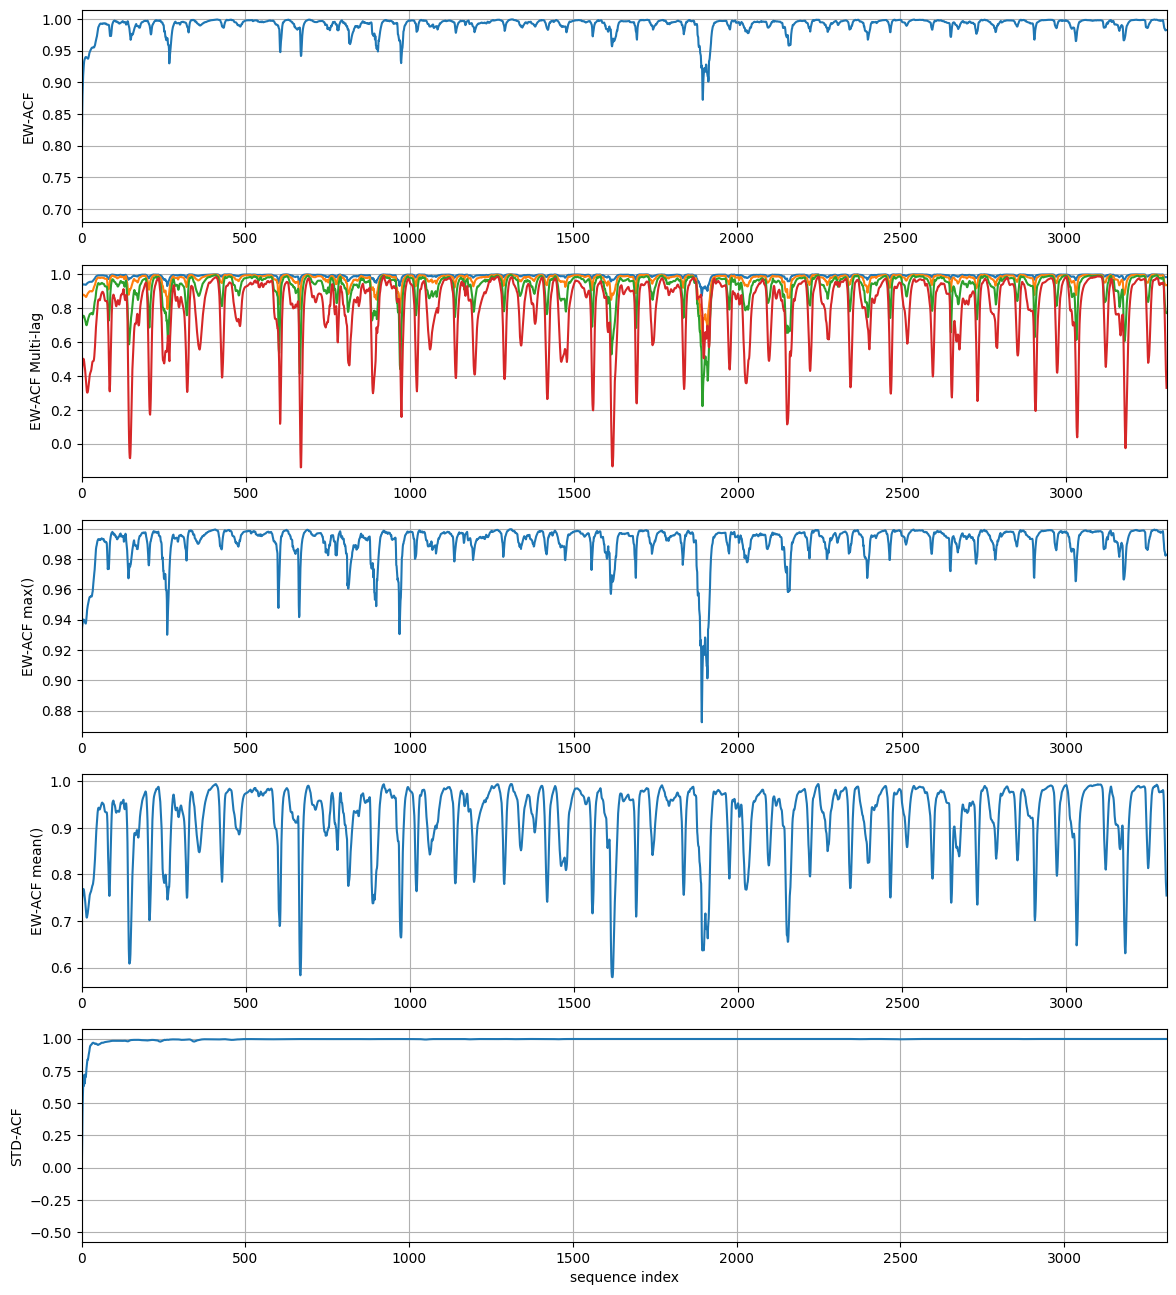

In [115]:
plt.figure(figsize=(14, 16))
plt.subplot(5, 1, 1)
plt.margins(x=0)
plt.grid(True)
plt.plot(ew_acf_seq)
plt.ylabel("EW-ACF")

plt.subplot(5, 1, 2)
plt.margins(x=0)
plt.grid(True)
plt.plot(engine_seq)
plt.ylabel("EW-ACF Multi-lag")

plt.subplot(5, 1, 3)
plt.margins(x=0)
plt.grid(True)
plt.plot(torch.max(engine_seq, dim=-1).values)
plt.ylabel("EW-ACF max()")

plt.subplot(5, 1, 4)
plt.margins(x=0)
plt.grid(True)
plt.plot(torch.mean(engine_seq, dim=-1))
plt.ylabel("EW-ACF mean()")

plt.subplot(5, 1, 5)
plt.margins(x=0)
plt.grid(True)
plt.plot(std_acf_seq)
plt.xlabel("sequence index")
plt.ylabel("STD-ACF")
plt.show()